**Task 1: Tabular Q-Learning Update**


In [1]:
import numpy as np

def init_q_table(n_states,n_actions):
    Q = np.zeros((n_states,n_actions))
    return Q

def q_update(Q, s, a, r, s_next, alpha, gamma):
    Q[s, a] += alpha * (r + gamma * np.max(Q[s_next, :]) - Q[s, a])
    return Q

**Task 2: ε-Greedy Policy on a Custom GridWorld**

In [2]:
import matplotlib.pyplot as plt

class GridWorld:
    def __init__(self):
        self.size = 5
        self.n_states = self.size * self.size
        self.n_actions = 4  # up, down, left, right
        self.goal = 25  # (4,4)
        self.pit = 23   # (2,4)
        self.reset()
    
    def reset(self):
        self.state = 0
        return self.state
    
    def step(self,action):
        #Take an action and return next state, reward & done flag
        row, col = divmod(self.state, self.size)
        if action == 0 and row > 0:  # up
            row -= 1
        elif action == 1 and row < self.size - 1:  # down
            row += 1
        elif action == 2 and col > 0:  # left
            col -= 1
        elif action == 3 and col < self.size - 1:  # right
            col += 1
            
        next_state = row * self.size + col
        reward = -1 
        done = False
        
        if next_state == self.goal:
            reward = 10
            done = True
        elif next_state == self.pit:
            reward = -10
            done = True
            
        self.state = next_state
        return next_state, reward, done


In [3]:
def select_action(Q,state,epsilon):
    if np.random.rand() < epsilon:
        # Explore
        action = np.random.randint(Q.shape[1])
    else:
        # Exploit
        action = np.argmax(Q[state, :])
    return action

In [4]:
def train_gridworld(env,epsilon,episodes=700,alpha=0.1,gamma=0.9):
    
    Q = init_q_table(env.n_states, env.n_actions)
    rewards = []
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action = select_action(Q, state, epsilon)
            next_state, reward, done = env.step(action)
            Q = q_update(Q, state, action, reward, next_state, alpha, gamma)
            total_reward += reward
            state = next_state
            
        rewards.append(total_reward)
    return rewards

In [5]:
def moving_average(data,ep_no):
    return np.convolve(data,np.ones(ep_no)/ep_no, mode='valid')


In [6]:
env=GridWorld()


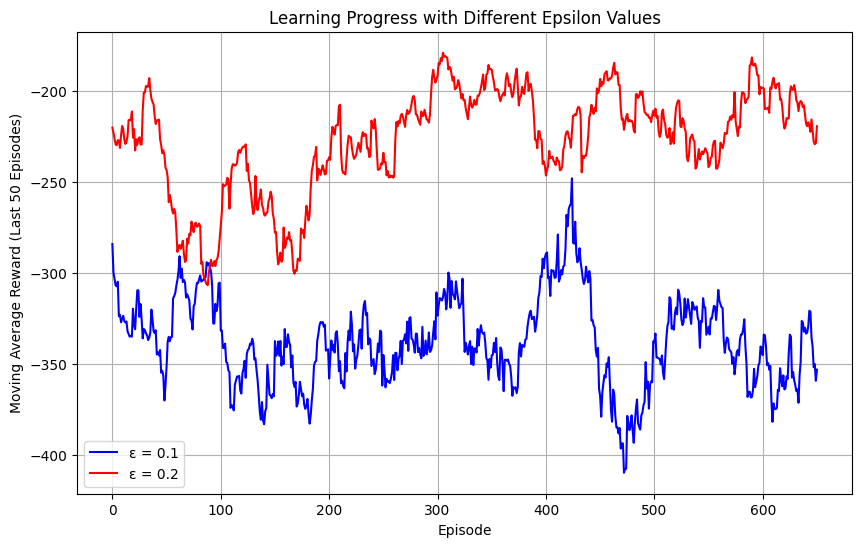

In [7]:
rewards_eps_01 = train_gridworld(env, epsilon=0.1)
rewards_eps_02 = train_gridworld(env, epsilon=0.2)

ep_no = 50
ma_rewards_eps_01 = moving_average(rewards_eps_01, ep_no)
ma_rewards_eps_02 = moving_average(rewards_eps_02, ep_no)

plt.figure(figsize=(10, 6))
plt.plot(range(len(ma_rewards_eps_01)), ma_rewards_eps_01, label='ε = 0.1', color='blue')
plt.plot(range(len(ma_rewards_eps_02)), ma_rewards_eps_02, label='ε = 0.2', color='red')
plt.xlabel('Episode')
plt.ylabel('Moving Average Reward (Last 50 Episodes)')
plt.title('Learning Progress with Different Epsilon Values')
plt.legend()
plt.grid(True)
plt.show()

**Task 3: Experience Replay Buffer**

In [8]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = [None] * capacity  
        self.position = 0 
        self.size = 0 

    def push(self, state, action, reward, next_state, done):
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity  
        self.size = min(self.size + 1, self.capacity)  
        
    def sample(self, batch_size):
        if self.size < batch_size:
            raise ValueError("self size < batch size")
        
        # Randomly sample indices from the current size of buffer
        indices = np.random.choice(self.size, batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        # Unzip the batch into separate arrays
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # Convert to numpy arrays
        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        next_states = np.array(next_states)
        dones = np.array(dones, dtype=np.uint8)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        #Return the current size of the buffer
        return self.size

In [9]:
def demonstrate_replay_buffer():
    buffer = ReplayBuffer(capacity=100)
    
    # Fill the buffer with 100 random transitions
    for _ in range(100):
        state = np.random.randint(0, 10) 
        action = np.random.randint(0, 4)  
        reward = np.random.uniform(-1.0, 1.0)  
        next_state = np.random.randint(0, 10)  
        done = np.random.choice([True, False])  
        buffer.push(state, action, reward, next_state, done)
    
    # Sample a batch of 32 transitions
    batch_size = 32
    states, actions, rewards, next_states, dones = buffer.sample(batch_size)
    
    # Print shapes and data types of the sampled batch
    print("Sampled Batch Details:")
    print(f"States - Shape: {states.shape}, Dtype: {states.dtype}")
    print(f"Actions - Shape: {actions.shape}, Dtype: {actions.dtype}")
    print(f"Rewards - Shape: {rewards.shape}, Dtype: {rewards.dtype}")
    print(f"Next States - Shape: {next_states.shape}, Dtype: {next_states.dtype}")
    print(f"Dones - Shape: {dones.shape}, Dtype: {dones.dtype}")

# Run the demonstration
demonstrate_replay_buffer()


Sampled Batch Details:
States - Shape: (32,), Dtype: int64
Actions - Shape: (32,), Dtype: int64
Rewards - Shape: (32,), Dtype: float64
Next States - Shape: (32,), Dtype: int64
Dones - Shape: (32,), Dtype: uint8


**Task 4: Deep Q-Network with Target Copy**


In [10]:
import torch
import torch.nn as nn

In [11]:
class DQNPolicy(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=2):
        super(DQNPolicy, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)


In [12]:
class DQNTarget(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=2):
        super(DQNTarget, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)

In [13]:
def update_target(policy_net, target_net):
    target_net.load_state_dict(policy_net.state_dict())


**Task 5: Full DQN Training Loop on CartPole-v1**

In [14]:
import gymnasium as gym
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

In [28]:
class DQNPolicy(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQNPolicy, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [24]:
class DQNTarget(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQNTarget, self).__init__()
        self.fc1 = nn.Linear(input_dim,32)
        self.fc2 = nn.Linear(32,32)
        self.fc3 = nn.Linear(32,output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [25]:
def update_target(policy_net, target_net):
    target_net.load_state_dict(policy_net.state_dict())

In [18]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))

    def __len__(self):
        return len(self.buffer)

In [19]:
def select_action(state, policy_net, epsilon, n_actions, device):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    else:
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = policy_net(state)
        return q_values.argmax().item()

In [34]:
N = 2000
X = 100
batch_size = 64
learning_rate = 0.0005
gamma = 0.99
replay_capacity = 10000
epsilon=1.0

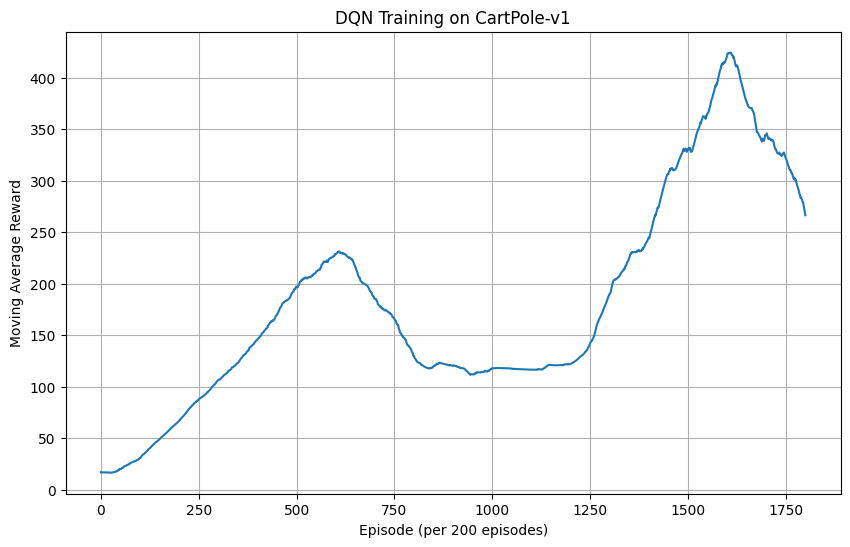

Success rate: 30.50%


In [35]:
env = gym.make('CartPole-v1')
input_dim = env.observation_space.shape[0]

n_actions = env.action_space.n

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

policy_net = DQNPolicy(input_dim, n_actions).to(device)
target_net = DQNTarget(input_dim, n_actions).to(device)
update_target(policy_net, target_net)

target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

replay_buffer = ReplayBuffer(replay_capacity)

episode_rewards = []

for episode in range(N):
    state, _ = env.reset()
    total_reward = 0

    done = False
    while not done:
        action = select_action(state, policy_net, epsilon, n_actions, device)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward


        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
            
            states = torch.FloatTensor(states).to(device)
            actions = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards = torch.FloatTensor(rewards).to(device)
            next_states = torch.FloatTensor(next_states).to(device)
            dones = torch.FloatTensor(dones).to(device)

            q_values = policy_net(states).gather(1, actions)

            with torch.no_grad():
                max_next_q_values = target_net(next_states).max(1)[0]  # Take only the values, not the tuple
                target_q_values = rewards + (1 - dones) * gamma * max_next_q_values
                target_q_values = target_q_values.unsqueeze(1)

            loss = criterion(q_values, target_q_values)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()    
            
    episode_rewards.append(total_reward)
    if (episode + 1) % X == 0:
        update_target(policy_net, target_net)

    epsilon = max(0.01, epsilon * 0.995)

window_size = N // 10
moving_avg_rewards = [np.mean(episode_rewards[i:i+window_size]) for i in range(N - window_size + 1)]

success_rate = sum(r >= 195 for r in episode_rewards) / N * 100

plt.figure(figsize=(10, 6))
plt.plot(range(len(moving_avg_rewards)), moving_avg_rewards)
plt.xlabel(f'Episode (per {window_size} episodes)')
plt.ylabel('Moving Average Reward')
plt.title('DQN Training on CartPole-v1')
plt.grid(True)
plt.show()

print(f'Success rate: {success_rate:.2f}%')